This analysis was done by Helana Solomon. I examined the accuracy of decision trees with and without demographic variables. For this notebook, I referenced geeksforgeeks, which helped me learn more about how to use sklearn as well as previous homework. I also referenced the scikit learn documentation for help on some functions.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import confusion_matrix,accuracy_score, ConfusionMatrixDisplay, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv("../Data/compas-scores-two-years.csv")

# filtering all data except relevant features

def get_columns_val(filtered = None):
    the_df = df.drop(columns=['id', 'name', 'first', 'last', 'dob', 'age_cat', 'type_of_assessment', 'compas_screening_date','c_case_number', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'decile_score', 'score_text', 'is_recid', 'is_violent_recid', 'event', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'start', 'end', 'c_jail_in', 'c_jail_out', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'vr_case_number', 'vr_charge_desc', 'vr_offense_date', 'screening_date', 'violent_recid', 'decile_score.1', 'priors_count.1', 'decile_score.1', 'days_b_screening_arrest', 'vr_charge_degree'])

    if filtered != None:
        the_df = the_df.drop(columns=['sex','age', 'race'])
    return the_df.columns


def filter_data():
    
    the_df = df.drop(columns=['id', 'name', 'first', 'last', 'dob', 'age_cat', 'type_of_assessment', 'compas_screening_date','c_case_number', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'decile_score', 'score_text', 'is_recid', 'is_violent_recid', 'event', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'start', 'end', 'c_jail_in', 'c_jail_out', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'vr_case_number', 'vr_charge_desc', 'vr_offense_date', 'screening_date', 'violent_recid', 'decile_score.1', 'priors_count.1', 'decile_score.1', 'days_b_screening_arrest', 'vr_charge_degree'])
    
    #print("columns: ", the_df.columns)
    new_df, column_names_per_encoder = label_encoder(the_df)
   
    
    X = new_df.iloc[:,0:9]
    y = new_df.iloc[:,9:10]

    group_info = the_df["race"].to_numpy()
       
    return X,y, column_names_per_encoder, group_info

# filter demographic info
def filter_data_no_demographics():
    group_info = df["race"].to_numpy()
    the_df = df.drop(columns=['id', 'name', 'sex','age', 'age_cat', 'type_of_assessment', 'race', 'first', 'last', 'dob', 'compas_screening_date','c_case_number', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'decile_score', 'score_text', 'is_recid', 'is_violent_recid', 'event', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'start', 'end', 'c_jail_in', 'c_jail_out', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'vr_case_number', 'vr_charge_desc', 'vr_offense_date', 'screening_date', 'violent_recid', 'decile_score.1', 'priors_count.1', 'decile_score.1', 'days_b_screening_arrest', 'vr_charge_degree'])
   
    #print("columns: ", the_df.columns)
   
    new_df, column_names_per_encoder = label_encoder(the_df)
    
    X = new_df.iloc[:,0:6]
    y = new_df.iloc[:,6:7]
    
    
    return X,y, column_names_per_encoder, group_info

# encode categorical variables
def label_encoder(data):
    label_encoder = LabelEncoder()
    class_names = {}

    for col in data.select_dtypes(include=['object']).columns:
        data[col] = label_encoder.fit_transform(data[col])
        class_names[col] = label_encoder.classes_
    return data, class_names
    
# spliting test and training data 
def split_data_set_DT(test_size=0.2, random_state=42, include_demographics = False):
    if include_demographics == True:
        X, y, cur_column_names_per_encoder, group = filter_data()
    else:
        X, y, cur_column_names_per_encoder, group = filter_data_no_demographics()
    X_train, X_test, y_train, y_test, gr_tr, gr_te = train_test_split(X, y, group, random_state=random_state, test_size=test_size)
    return X_train, X_test, y_train, y_test, cur_column_names_per_encoder, gr_tr, gr_te




In [3]:
# This could have been one function but for my own testing I made them two distinct functions to follow various naming conventions

# train with gini index with demographics
def training_data_all_features(X_train, y_train):
    decision_tree = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5)
    decision_tree.fit(X_train, y_train)
    return decision_tree

# train with gini index without demographics
def training_data_without_demographics(X_train, y_train):
    decision_tree = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5)
    decision_tree.fit(X_train, y_train)
    return decision_tree

In [4]:
# making predictions
def prediction(DTC_object, X_test):
    y_pred = DTC_object.predict(X_test)
    #print("Predicted Values: \n", y_pred)
    return y_pred

In [5]:
# evaluate the model's accuracy
def accuracy(y_test, y_pred):
    return accuracy_score(y_test, y_pred) 

# using built in function to find precision
def get_percision(y_test, y_pred):
    return precision_score(y_test, y_pred)
# using built in function to find recall
def get_recall(y_test, y_pred):
    return recall_score(y_test, y_pred)

# display confusion matrix of true positives, false positives, false negatives and true negatives
def get_confusion_matrix(y_test, y_pred):
    matrix = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(matrix)
    disp.plot()
    plt.show()


In [6]:
# plot the model 

def plot_decision_tree(clf_object, feature_names, class_names, file_name):
    plt.figure(figsize=(15,10))
    # changing type for graph
    class_names = class_names.astype("str")
    plot_tree(clf_object, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
    plt.savefig(file_name)
    plt.show()

In [7]:
# find the distinct classes of demographics 
def accuracy_per_class(X_test_val, y_test_val, group_true, curr_decision_tree, col_names_per_encoder= None):
    unique_values = np.unique(group_true)
    #idx = (arr[:, ""])
    #print(X_test.shape, y_test.shape)
    for i in range(len(unique_values)):
        new_X_test = X_test_val[group_true == unique_values[i]]
        new_Y_test = y_test_val[group_true == unique_values[i]]
    
    
        y_pred_class = prediction(curr_decision_tree, new_X_test)
        if col_names_per_encoder != None:
            print("Race correlated with:" , col_names_per_encoder["race"][i], "code:", unique_values[i])
        else:

            print("Race correlated with:", unique_values[i], i)
        print("accuracy", accuracy(new_Y_test, y_pred_class))
        print("recall", get_recall(new_Y_test, y_pred_class))
        print("percision", get_percision(new_Y_test, y_pred_class))
        print("\n")



In [8]:
# calulating equalized odds
def equalized_odds(y_true_labels, y_predictions, grouping):
    print(grouping)
    tr_pos, flse_neg = [], []
   
    unqiue_group = np.unique(grouping)
    sorted_grouping = np.sort(unqiue_group)

    for group in sorted_grouping:
        group_index = (grouping == group)
        group_labels = y_true_labels[group_index]
        group_predictions = y_predictions[group_index]
        confusion_matrix_val =  confusion_matrix(group_labels, group_predictions)
        
        top_row, bottom_row = confusion_matrix_val
        true_pos, false_pos = top_row
        false_neg, true_neg = bottom_row
       
        true_positive = float(true_pos / (true_pos + false_neg))
        false_positive = float(false_pos / (false_pos + true_neg))
        tr_pos.append(true_positive)
        flse_neg.append(false_positive)
    return tr_pos, flse_neg



While examining the results below you can find that the difference the accuracies between the two models is very small.

Results with Demographic Info
The accuracy of this decision tree is: 0.6895356895356896
Plotting Decision Tree


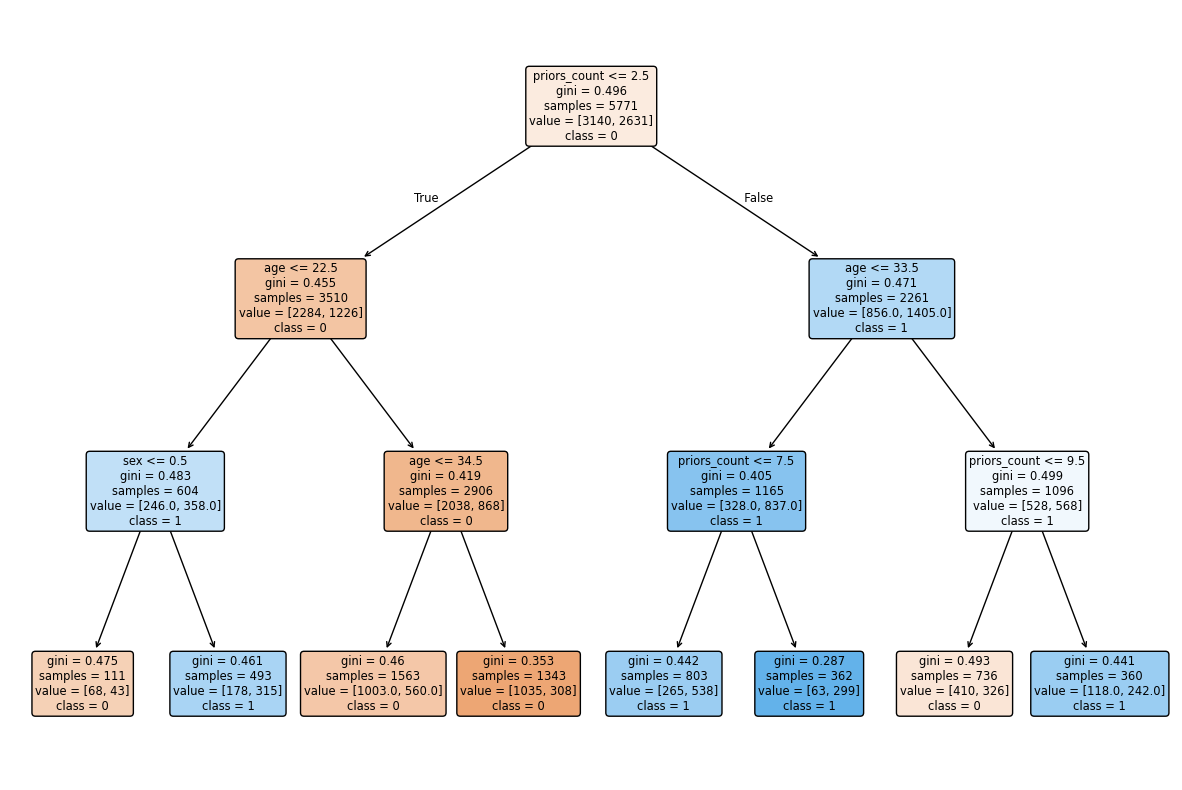

In [9]:
print("Results with Demographic Info")

# get training and test data
with_demo_X_train, with_demo_X_test, with_demo_y_train, with_demo_y_test, with_demo_cur_column_names_per_encoder, gr_tr, gr_te = split_data_set_DT(include_demographics = True)
# train data
decision_tree_with_demo = training_data_all_features(with_demo_X_train, with_demo_y_train)
# predict
y_pred = prediction(decision_tree_with_demo, with_demo_X_test)
# get accuracy 
with_demo_accuracy = accuracy(with_demo_y_test, y_pred)

with_demo_precision =  get_percision(with_demo_y_test, y_pred)
with_demo_recall = get_recall(with_demo_y_test, y_pred)


print("The accuracy of this decision tree is:", with_demo_accuracy)
print("Plotting Decision Tree")
plot_decision_tree(decision_tree_with_demo, decision_tree_with_demo.feature_names_in_, decision_tree_with_demo.classes_, "images/results_with_demo_graphic_info.png")

This examines the truth labels versus the predicted labels for this model. We can see that for a model with demographic variables, the false positives and true negatives are relatively smaller than the true positives.

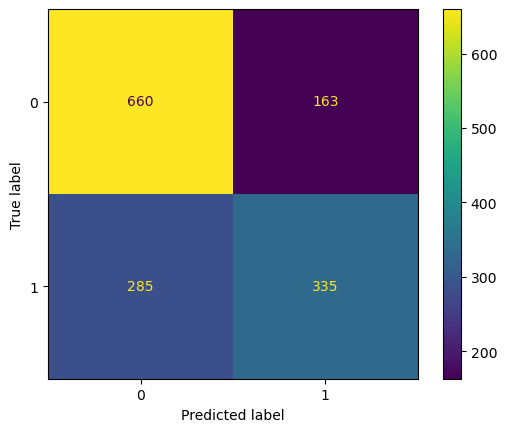

In [10]:
get_confusion_matrix(with_demo_y_test, y_pred)

Results Without Demographic Information
The accuracy of this decsion tree is: 0.6673596673596673
Plotting Decision Tree


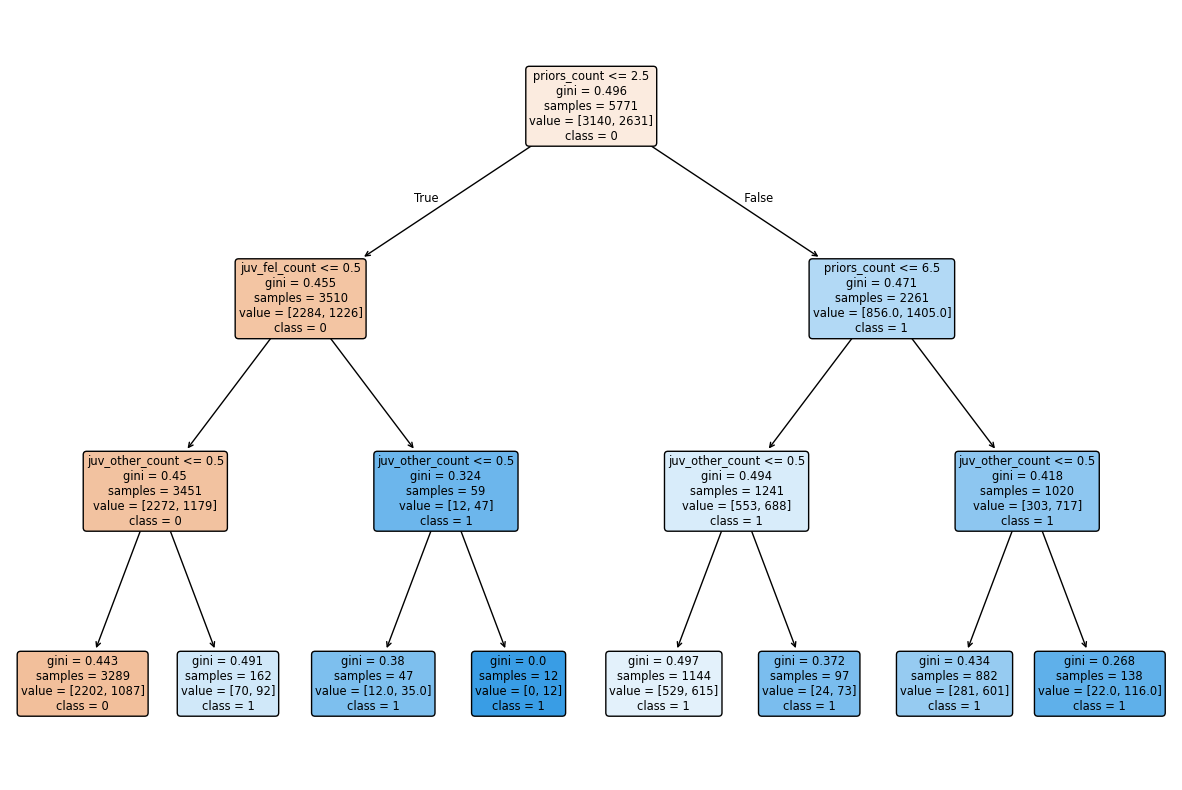

In [11]:


print("Results Without Demographic Information")
# get training and test data
without_demo_X_train, without_demo_X_test, without_demo_y_train, without_demo_y_test , without_demo_cur_column_names_per_encoder, no_g_tr, no_g_te = split_data_set_DT(include_demographics=False)

# train data
second_decision_tree = training_data_without_demographics(without_demo_X_train, without_demo_y_train)

#predict
y_pred_curr = prediction(second_decision_tree, without_demo_X_test)

# get accuracy 
no_demo_accuracy = accuracy(without_demo_y_test, y_pred_curr)
no_demo_precision = get_percision(without_demo_y_test, y_pred_curr)
no_demo_recall = get_recall(without_demo_y_test, y_pred_curr)

# plot data
print("The accuracy of this decsion tree is:", no_demo_accuracy)
print("Plotting Decision Tree")
plot_decision_tree(second_decision_tree, second_decision_tree.feature_names_in_, second_decision_tree.classes_, "images/results_without_demographic_information")



This examines the truth labels versus the predicted labels for this model. We can see that when we remove the demographic variables, the false positives and true negatives increase and the overall true positives significantly decrease.

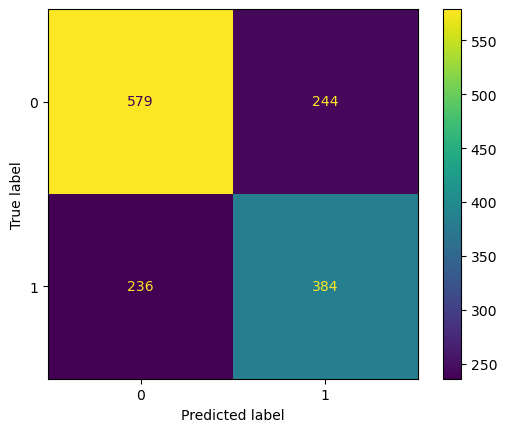

In [12]:

get_confusion_matrix(without_demo_y_test, y_pred_curr)

In [13]:
print("#########")
print("ACCURACY PER CLASS WITH DEMOGRAPHIC FEATURES")
print("#########")
accuracy_per_class(with_demo_X_test, with_demo_y_test, gr_te, decision_tree_with_demo, with_demo_cur_column_names_per_encoder)


#########
ACCURACY PER CLASS WITH DEMOGRAPHIC FEATURES
#########
Race correlated with: African-American code: 0
accuracy 0.6949384404924761
recall 0.6451612903225806
percision 0.7250755287009063


Race correlated with: Asian code: 1
accuracy 0.6
recall 0.0
percision 0.0


Race correlated with: Caucasian code: 2
accuracy 0.689108910891089
recall 0.3945945945945946
percision 0.6186440677966102


Race correlated with: Hispanic code: 3
accuracy 0.6837606837606838
recall 0.35294117647058826
percision 0.4444444444444444


Race correlated with: Native American code: 4
accuracy 0.6666666666666666
recall 1.0
percision 0.5


Race correlated with: Other code: 5
accuracy 0.6585365853658537
recall 0.3333333333333333
percision 0.47368421052631576




In [14]:
print("#########")
print("ACCURACY PER CLASS WITHOUT DEMOGRAPHIC FEATURES")
print("#########")
accuracy_per_class(without_demo_X_test, without_demo_y_test, no_g_te, second_decision_tree)

#########
ACCURACY PER CLASS WITHOUT DEMOGRAPHIC FEATURES
#########
Race correlated with: African-American 0
accuracy 0.6484268125854993
recall 0.6720430107526881
percision 0.6493506493506493


Race correlated with: Asian 1
accuracy 0.8
recall 1.0
percision 0.5


Race correlated with: Caucasian 2
accuracy 0.695049504950495
recall 0.5837837837837838
percision 0.5837837837837838


Race correlated with: Hispanic 3
accuracy 0.6581196581196581
recall 0.38235294117647056
percision 0.40625


Race correlated with: Native American 4
accuracy 0.6666666666666666
recall 1.0
percision 0.5


Race correlated with: Other 5
accuracy 0.6707317073170732
recall 0.4074074074074074
percision 0.5




When we examine equalized odds in terms of race, we find that both models fail this fairness metrics as all the true positives and false negative values are differ across different demographic groups. This means that both models are not treating the all groups fairly and there is some bias within the model. 

In [15]:
train_true_positives, train_false_negatives = equalized_odds(with_demo_y_train, prediction(decision_tree_with_demo, with_demo_X_train), gr_tr)
test_true_positives, test_false_negatives = equalized_odds(with_demo_y_test, prediction(decision_tree_with_demo, with_demo_X_test),gr_te)

print("#########")
print("FOR MODEL WITH DEMOGRAPHIC FEATURES")
print("#########")

print("\n", np.unique(no_g_te))
print("Training:")
print("True Positives", train_true_positives)
print("False Negatives", train_false_negatives)

print("\n", np.unique(no_g_tr))
print("\nTesting:")
print("True Positives", test_true_positives)
print("False Negatives", test_false_negatives)

[2 0 0 ... 2 0 0]
[2 0 0 ... 2 2 2]
#########
FOR MODEL WITH DEMOGRAPHIC FEATURES
#########

 ['African-American' 'Asian' 'Caucasian' 'Hispanic' 'Native American'
 'Other']
Training:
True Positives [0.6373693915181315, 0.7727272727272727, 0.6840324763193505, 0.7103274559193955, 0.8333333333333334, 0.7354260089686099]
False Negatives [0.2982062780269058, 0.4, 0.3333333333333333, 0.3252032520325203, 0.1111111111111111, 0.3472222222222222]

 ['African-American' 'Asian' 'Caucasian' 'Hispanic' 'Native American'
 'Other']

Testing:
True Positives [0.67, 0.75, 0.710594315245478, 0.7555555555555555, 1.0, 0.7142857142857143]
False Negatives [0.27492447129909364, 1.0, 0.3813559322033898, 0.5555555555555556, 0.5, 0.5263157894736842]


In [16]:

no_train_true_positives, no_train_false_negatives = equalized_odds(without_demo_y_train, prediction(second_decision_tree, without_demo_X_train), no_g_tr)
no_test_true_positives, no_test_false_negatives = equalized_odds(without_demo_y_test, prediction(second_decision_tree, without_demo_X_test),no_g_te)


print("#########")
print("FOR MODEL WITHOUT DEMOGRAPHIC FEATURES")
print("#########")

print("\n", np.unique(no_g_te))
print("Training:")
print("True Positives", no_train_true_positives)
print("False Negatives", no_train_false_negatives)

print("\n", np.unique(no_g_tr))
print("\nTesting:")
print("True Positives", no_test_true_positives)
print("False Negatives", no_test_false_negatives)

['Caucasian' 'African-American' 'African-American' ... 'Caucasian'
 'African-American' 'African-American']
['Caucasian' 'African-American' 'African-American' ... 'Caucasian'
 'Caucasian' 'Caucasian']
#########
FOR MODEL WITHOUT DEMOGRAPHIC FEATURES
#########

 ['African-American' 'Asian' 'Caucasian' 'Hispanic' 'Native American'
 'Other']
Training:
True Positives [0.6332863187588152, 0.8181818181818182, 0.6857142857142857, 0.7087912087912088, 0.8333333333333334, 0.726027397260274]
False Negatives [0.3477698771816419, 0.2, 0.4412191582002903, 0.41025641025641024, 0.1111111111111111, 0.39473684210526316]

 ['African-American' 'Asian' 'Caucasian' 'Hispanic' 'Native American'
 'Other']

Testing:
True Positives [0.6473988439306358, 1.0, 0.759375, 0.7529411764705882, 1.0, 0.7333333333333333]
False Negatives [0.35064935064935066, 0.5, 0.41621621621621624, 0.59375, 0.5, 0.5]


When examining demographic parity, we found that for both models, they predicted that black individuals would reoffense within two years. Suprisingly, for the model without demographics, the parity differences between the two groups is smaller than the model with demographics. This indicates that there maybe some more underlying infromation causing bias within the models.

In [17]:
def demographic_parity_test(y_true, y_pred_val, group):
    total_white = 0
    total_black = 0

    black_count = 0
    white_count = 0
    
    for i in range(len(y_true)-1):
       
        if group[i] == 2:
            
            total_white +=1
           
            if y_pred_val[i] == 1:
                
                white_count+=1
        elif group[i] == 0:
          
            total_black+=1
            if y_pred_val[i] == 1:
                
                black_count +=1


    group_two_parity = white_count / total_white
    group_five_parity = black_count / total_black
    return group_two_parity - group_five_parity

print("#########")
print("FOR MODEL WITH DEMOGRAPHIC FEATURES")
print("#########")
training_demo_parity = demographic_parity_test(with_demo_y_train, prediction(decision_tree_with_demo, with_demo_X_train), gr_tr)
test_demo_parity = demographic_parity_test(with_demo_y_test, prediction(decision_tree_with_demo, with_demo_X_test), gr_te)
print("Training With Demographic Information:", training_demo_parity)
print("Testing With Demographic Information", test_demo_parity)

#########
FOR MODEL WITH DEMOGRAPHIC FEATURES
#########
Training With Demographic Information: -0.20975461307885493
Testing With Demographic Information -0.22066152042212234


In [18]:
def demographic_parity_test_without_demo(y_true, y_pred_val, group):
    total_white = 0
    total_black = 0

    black_count = 0
    white_count = 0
    
    for i in range(len(y_true)-1):
       
        if group[i] == "Caucasian":
            
            total_white +=1
           
            if y_pred_val[i] == 1:
                
                white_count+=1
        elif group[i] == "African-American":
          
            total_black+=1
            if y_pred_val[i] == 1:
                
                black_count +=1


    group_two_parity = white_count / total_white
    group_five_parity = black_count / total_black
    return group_two_parity - group_five_parity

print("#########")
print("FOR MODEL WITHOUT DEMOGRAPHIC FEATURES")
print("#########")
no_training_demo_parity = demographic_parity_test_without_demo(without_demo_y_train, prediction(second_decision_tree, without_demo_X_train), no_g_tr)
no_test_demo_parity = demographic_parity_test_without_demo(without_demo_y_test, prediction(second_decision_tree, without_demo_X_test), no_g_te)
print("Training without Demographic Information:", no_training_demo_parity)
print("Testing without Demographic Information", no_test_demo_parity)

#########
FOR MODEL WITHOUT DEMOGRAPHIC FEATURES
#########
Training without Demographic Information: -0.16841520167787344
Testing without Demographic Information -0.16159642151434223


The following code looks at feature demographics for the two models to see which of the features are more predictive. 

/var/folders/nz/_rbx6y750f59t_xjc4by9q0c0000gn/T/ipykernel_48568/2975314934.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


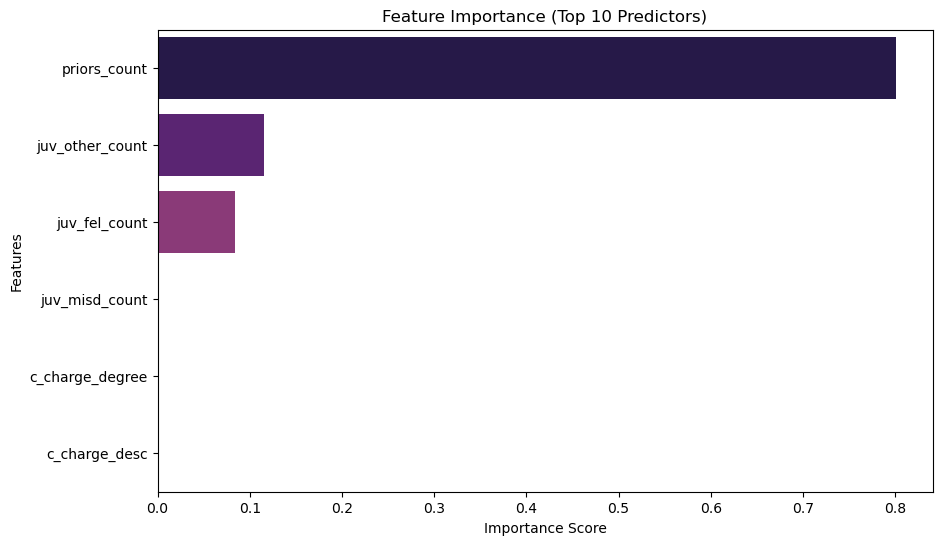

In [22]:
feature_names = get_columns_val("True")
feature_names= feature_names[0:len(feature_names)- 1]
importances = second_decision_tree.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')

plt.title('Feature Importance (Top 10 Predictors)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.savefig("images/feature_importance_no_demographics.png")
plt.show()

/var/folders/nz/_rbx6y750f59t_xjc4by9q0c0000gn/T/ipykernel_48568/2454714160.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


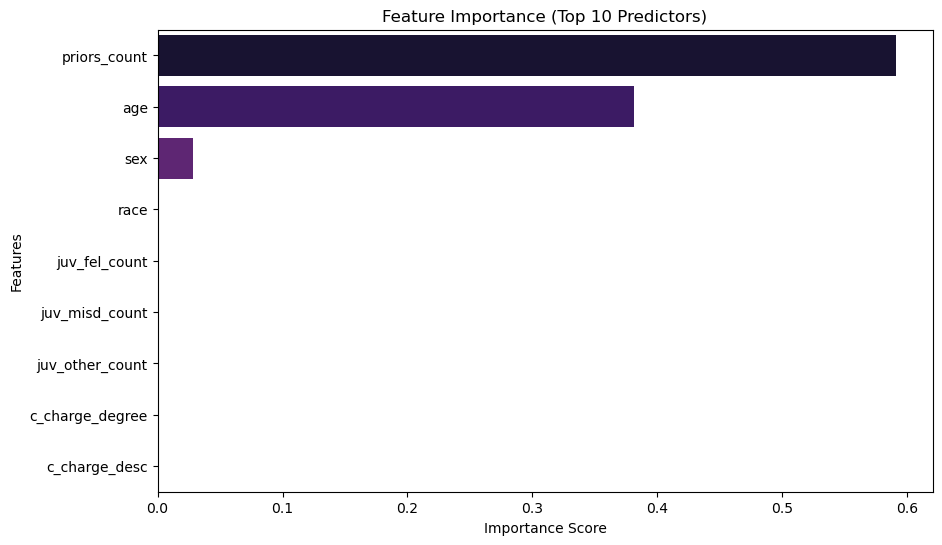

In [20]:
# Plotting feature importances
feature_names = get_columns_val()
feature_names= feature_names[0:len(feature_names)- 1]
importances = decision_tree_with_demo.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')

plt.title('Feature Importance (Top 10 Predictors)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.savefig("images/feature_importance_demographics.png")
plt.show()

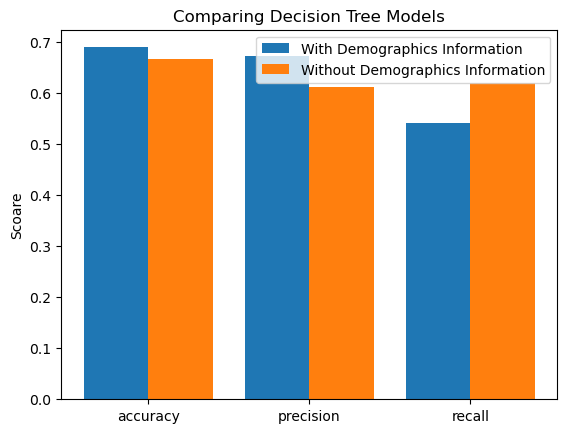

In [21]:
all_metrics_with_demo = [with_demo_accuracy, with_demo_precision, with_demo_recall]

all_metrics_without_demo = [no_demo_accuracy, no_demo_precision, no_demo_recall]

graph_labels = ["accuracy", "precision", "recall"]

x = np.arange(len(graph_labels))

plt.bar(x - 0.2, all_metrics_with_demo, width = 0.4, label = "With Demographics Information")
plt.bar(x +0.2, all_metrics_without_demo, width = 0.4, label = "Without Demographics Information")

plt.xticks(x, graph_labels)
plt.ylabel("Scoare")
plt.title("Comparing Decision Tree Models")
plt.legend()
plt.savefig("images/model_comparison.png")
plt.show()